[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lmassaron/gemma_from_scratch/blob/main/workshop/05_gated_mlp.ipynb)


# Workshop: Building Gemma 3 from Scratch

[<- Previous: 04 Rotary Positional Embedding.ipynb](04_rotary_positional_embeddings.ipynb) | [Next: 06 RMSnorm and normalization ->](06_rmsnorm_and_normalization.ipynb)

## Notebook 5: Gated MLP (GeGLU)

**Estimated Time: 10 minutes**

In addition to attention, transformers use a Feed-Forward Network (FFN) to process each token. Gemma 3 uses **GeGLU (Gated GELU Universal Linear Unit)**. This is a key difference from Gemma 2, which used SwiGLU.

---

## Learning Objectives:
1. Understand the GeGLU architecture.
2. Implement the `gate_proj`, `up_proj`, and `down_proj` logic.
3. Compare GELU with standard ReLU and understand why GELU matters.
4. Understand why GeGLU is preferred over SwiGLU in Gemma 3.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math
import sys

print(f"Python version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")

emb_dim = 768  # Gemma 3 hidden_size
hidden_dim = 2048  # Gemma 3 intermediate_size
sliding_window = 1024

Python version: 3.12.0 (main, Oct  2 2023, 20:56:14) [Clang 16.0.3 ]
PyTorch version: 2.12.0


---

## 1. Activation Functions: GELU

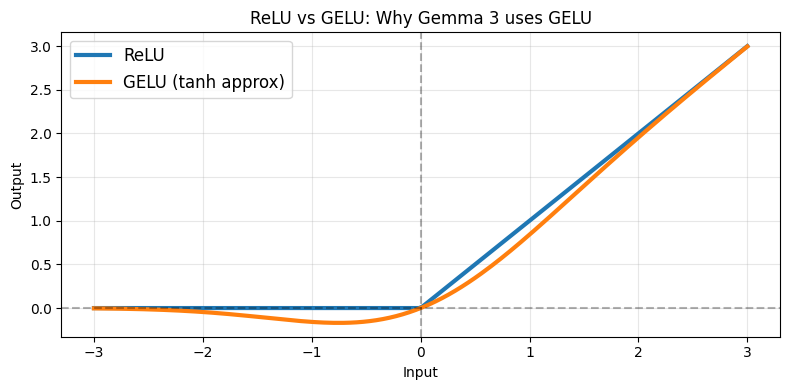

In [2]:
# Compare GELU vs ReLU
x = torch.linspace(-3, 3, 200)
y_relu = F.relu(x)
y_gelu = F.gelu(x, approximate="tanh")  # tanh approximation for speed

plt.figure(figsize=(8, 4))
plt.plot(x.numpy(), y_relu.numpy(), label="ReLU", linewidth=3)
plt.plot(x.numpy(), y_gelu.numpy(), label="GELU (tanh approx)", linewidth=3)
plt.axhline(y=0, color="k", linestyle="--", alpha=0.3)
plt.axvline(x=0, color="k", linestyle="--", alpha=0.3)
plt.legend(loc="upper left", fontsize=12)
plt.title("ReLU vs GELU: Why Gemma 3 uses GELU")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [3]:
print("Key difference:")
print(
    f"  At x=-1: ReLU={F.relu(torch.tensor(-1.0)).item():.3f}, GELU={F.gelu(torch.tensor(-1.0), approximate='tanh').item():.3f}"
)
print(
    f"  At x=0:  ReLU={F.relu(torch.tensor(0.0)).item():.3f}, GELU={F.gelu(torch.tensor(0.0), approximate='tanh').item():.3f}"
)
print(
    f"  At x=1:  ReLU={F.relu(torch.tensor(1.0)).item():.3f}, GELU={F.gelu(torch.tensor(1.0), approximate='tanh').item():.3f}"
)
print()
print("GELU has a small dip in negative territory, giving smoother gradient flow.")

Key difference:
  At x=-1: ReLU=0.000, GELU=-0.159
  At x=0:  ReLU=0.000, GELU=0.000
  At x=1:  ReLU=1.000, GELU=0.841

GELU has a small dip in negative territory, giving smoother gradient flow.


Gradient flow:

* The Smooth Curve: There are no sharp corners. As $x$ approaches zero, the line gently curves upwards. Because the curve is smooth everywhere, the gradient (the slope) transitions smoothly from near-zero to one. The optimizer can "glide" down the loss landscape instead of bouncing off sharp edges.
* The Negative Dip: As you noted, for small negative numbers (like $-1.0$), GELU doesn't just output zero. It dips slightly below the x-axis, returning a small negative number.

---

## 🚪 Gemma 3's Gated MLP: GeGLU Architecture

Standard Transformer blocks use a two-projection feed-forward network: $\text{Output} = \text{Linear}_2(\text{GELU}(\text{Linear}_1(x)))$. The MLP is just two matrices: an up-projection, an activation function, and a down-projection.

Gemma 3 uses **GeGLU (GELU-based Gated Linear Unit)** instead. This architecture uses **three linear projections** to dynamically filter information.

                         [ Input Vector (x) ]
                                 │
                 ┌───────────────┴───────────────┐
                 │                               │
          (Linear Layer W)                (Linear Layer V)
                 │                               │
          [ Gate Path ]                   [ Content Path ]
           Math: (xW)                      Math: (xV)
                 │                               │
         (GELU Activation)                       │
                 │                               │
        [ Activated Gate ]                       │
    (Values pushed to ~0 or 1)                   │
                 │                               │
                 └───────────────┬───────────────┘
                                 │
                    ( Element-wise Multiply ⊗ )
                                 │
                        [ Output Vector ]

### 🧮 Mathematical Formulation:
Instead of a static activation function, we project the input $x$ into a gate branch and an up-projection branch:

$$\text{Gate Branch: } g(x) = W_{gate} x$$

$$\text{Up Branch: } u(x) = W_{up} x$$

We apply the GELU activation to the gate branch, then perform element-wise multiplication (Hadamard product $\odot$) with the up branch:

$$\text{Intermediate Output: } h(x) = \text{GELU}(g(x), \text{approximate="tanh"}) \odot u(x)$$

Finally, we project the gated features back to the hidden size:

$$\text{Output: } y = h(x) W_{down}$$

### 🧠 Why is Gating Beneficial?
Gating acts as a **dynamic, learned per-token filter**. The model learns to suppress irrelevant dimensions and amplify important ones based on the context of each token, providing much higher capacity than static activations!

In [4]:
class GatedMLP(nn.Module):
    """
    Gemma 3 GeGLU (GELU-based Gated MLP).

    Architecture: x -> gate_proj -> GELU -> element-wise multiply with up_proj -> down_proj
    """

    def __init__(self, d_in, d_hidden):
        super().__init__()
        # Three projections: gate (uses GELU), up (identity), down (output)
        self.gate_proj = nn.Linear(d_in, d_hidden, bias=False)
        self.up_proj = nn.Linear(d_in, d_hidden, bias=False)
        self.down_proj = nn.Linear(d_hidden, d_in, bias=False)

    def forward(self, x):
        # 1. Compute gate and up projections
        gate = self.gate_proj(x)
        up = self.up_proj(x)

        # 2. Apply GELU activation to gate, then element-wise multiply
        # Gemma 3 uses tanh approximation for GELU (same as SiLU in SwiGLU)
        activated_gate = F.gelu(gate, approximate="tanh")
        intermediate = activated_gate * up

        # 3. Project back to input dimension
        return self.down_proj(intermediate)


mlp = GatedMLP(emb_dim, hidden_dim)
sample_input = torch.randn(1, 10, emb_dim)
output = mlp(sample_input)
print(f"Input shape:  {sample_input.shape}")
print(f"Output shape: {output.shape}")
assert output.shape == sample_input.shape
print("✅ GeGLU MLP works correctly!")

Input shape:  torch.Size([1, 10, 768])
Output shape: torch.Size([1, 10, 768])
✅ GeGLU MLP works correctly!


---

## 3. Comparing GeGLU to a Standard MLP

In [5]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


gated_params = count_parameters(mlp)
print(f"GeGLU MLP parameters: {gated_params:,}")
print(f"  gate_proj:  emb 	imes hidden = {emb_dim * hidden_dim:,}")
print(f"  up_proj:    emb 	imes hidden = {emb_dim * hidden_dim:,}")
print(f"  down_proj:  hidden 	imes emb   = {hidden_dim * emb_dim:,}")

# Define a standard MLP (just one up + down)
standard_mlp = nn.Sequential(
    nn.Linear(emb_dim, hidden_dim, bias=False),
    nn.Linear(hidden_dim, emb_dim, bias=False),
)
standard_params = count_parameters(standard_mlp)
print(f"\nStandard MLP parameters: {standard_params:,}")
print(
    f"\nGeGLU has {gated_params - standard_params:,} more parameters (+{(gated_params / standard_params - 1) * 100:.0f}%)"
)
print(
    "This extra capacity is why GeGLU needs a larger intermediate_size than hidden_size."
)

GeGLU MLP parameters: 4,718,592
  gate_proj:  emb 	imes hidden = 1,572,864
  up_proj:    emb 	imes hidden = 1,572,864
  down_proj:  hidden 	imes emb   = 1,572,864

Standard MLP parameters: 3,145,728

GeGLU has 1,572,864 more parameters (+50%)
This extra capacity is why GeGLU needs a larger intermediate_size than hidden_size.


---

## 4. Gating Explained

Gating allows the model to dynamically control information flow for each token:

- `gate_proj` decides **which features** from the input to pass through
- `up_proj` projects to a **higher-dimensional space** for richer computation
- `down_proj` projects back to the original dimension

The gate acts as a **per-token, per-feature filter** -- not a static activation.

---

## 5. Comparing Gated MLPs: GeGLU (Gemma 3) vs SwiGLU (Gemma 2 & Others)

Gated MLPs are standard in modern large language models, but different architectural families have different preferences for the gating activation.

### 📐 Activation Differences:
- **Gemma 3 (GeGLU)**: Gates using the **GELU** (Gaussian Error Linear Unit) activation.

  $$\text{Gate}(x) = \text{GELU}(W_{gate} x)$$

- **Gemma 2 & Other Families (SwiGLU)**: Models like Gemma 2 and Llama 3 gate using the **SiLU** (Sigmoid Linear Unit / Swish) activation.

  $$\text{Gate}(x) = \text{SiLU}(W_{gate} x) = (W_{gate} x) \cdot \sigma(W_{gate} x)$$

Both variants use three projection matrices and have the exact same parameter counts. The choice between GeGLU and SwiGLU is a design preference; Gemma's engineering team has found that the GELU activation provides superior stability and training dynamics for their specific pre-training recipes in Gemma 3.

In [6]:
class SwiGLU(nn.Module):
    """SwiGLU variant used in Llama 3 (while Gemma 3 uses GeGLU)."""

    def __init__(self, d_in, d_hidden):
        super().__init__()
        self.gate_proj = nn.Linear(d_in, d_hidden, bias=False)
        self.up_proj = nn.Linear(d_in, d_hidden, bias=False)
        self.down_proj = nn.Linear(d_hidden, d_in, bias=False)

    def forward(self, x):
        gate = self.gate_proj(x)
        up = self.up_proj(x)
        # SiLU = x * sigmoid(x) -- this is the SwiGLU difference
        activated_gate = F.silu(gate)  # Same as F.swish(gate)
        intermediate = activated_gate * up
        return self.down_proj(intermediate)


swiglu = SwiGLU(emb_dim, hidden_dim)
print(f"SwiGLU parameters: {count_parameters(swiglu):,}")
print(f"GeGLU parameters:  {count_parameters(mlp):,}")
print("\nBoth have the same parameter count -- the difference is just GELU vs SiLU.")

SwiGLU parameters: 4,718,592
GeGLU parameters:  4,718,592

Both have the same parameter count -- the difference is just GELU vs SiLU.


---

## Key Takeaway

Gemma 3 GeGLU uses GELU gating with three projections:
- `gate_proj` → GELU(gate)
- `up_proj` → identity
- `down_proj` → output

This is different from Llama 3 and Gemma 2, which used SwiGLU (SiLU gating). Gemma 3 switched to GeGLU because GELU works better for their updated training data and architecture.
